In [1]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import numpy as np
import os
import glob
import json
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, BoundaryNorm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import nctoolkit as nc
import geopandas
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, BoundaryNorm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import pandas as pd
from windspharm.xarray import VectorWind
import metpy.calc as mpcalc
from metpy.units import units
from tqdm import tqdm 

def get_GADI_ERA5_filename(invar,indt,stream='hourly',level_type='potential-temperature',**kwargs):
    yyyy=indt.strftime('%Y')
    mm=indt.strftime('%m')
    emd=datetime(int(yyyy),int(mm),1)+relativedelta(months=1)-relativedelta(days=1)
    emd_str=emd.strftime('%Y%m%d')

    if level_type=='potential-temperature':
        gadiproj='uc16'
        levtype='pt'
        if stream=='hourly':
            era5stream='oper'
            era5streamdir='oper'
        if stream=='monthly':
            era5stream='mnth'
            era5streamdir='mnth'
        filename=invar+'_era5_'+levtype+'_'+era5stream+'_an_'+yyyy+mm+'01-'+emd_str+'.nc'
    if level_type=='potential-vorticity':
        gadiproj='uc16'
        levtype='pv'
        if stream=='hourly':
            era5stream='oper'
            era5streamdir='oper'
        if stream=='monthly':
            era5stream='mnth'
            era5streamdir='mnth'
        filename=invar+'_era5_'+levtype+'_'+era5stream+'_an_'+yyyy+mm+'01-'+emd_str+'.nc'
    if level_type=='pressure-levels':
        gadiproj='rt52'
        levtype='pl'
        if stream=='hourly':
            era5stream='oper'
            era5streamdir='reanalysis'
        if stream=='monthly':
            era5stream='moda'
            era5streamdir='monthly-averaged'
        filename=invar+'_era5_'+era5stream+'_'+levtype+'_'+yyyy+mm+'01-'+emd_str+'.nc'
    if level_type=='single-levels':
        gadiproj='rt52'
        levtype='sfc'
        if stream=='hourly':
            era5stream='oper'
            era5streamdir='reanalysis'
        filename=invar+'_era5_'+era5stream+'_'+levtype+'_'+yyyy+mm+'01-'+emd_str+'.nc'
        
    ncpath='/g/data/'+gadiproj+'/era5/'+level_type+'/'+era5streamdir+'/'+invar+ '/'+yyyy+'/'+filename
    
    return ncpath


nctoolkit is using Climate Data Operators version 2.1.0


In [2]:
import sys
sys.path.append('/g/data/gb02/mb0427/wxlib/lib/')

In [3]:
from utils.gridlib import grid
import datetime as dt

indt=datetime(2022,3,1)
fn=xr.open_dataset(get_GADI_ERA5_filename('pv',indt,level_type='potential-temperature'))
pv=fn.resample(time='6h').nearest()
#pv=pv.reindex(latitude=list(reversed(pv.latitude)))
pv=pv.sel(level=330).isel(time=slice(0,4))

gridobj=grid
gridobj.x,gridobj.y=np.meshgrid(pv.longitude.values,pv.latitude.values)
gridobj.nt,gridobj.ny,gridobj.nx=pv.pv.shape
#gridobj.nt,gridobj.nz,gridobj.ny,gridobj.nx=pv.pv.shape
gridobj.t=pv.time.values
gridobj.t_parsed=np.array([dt.datetime.strptime(str(tt),'%Y-%m-%dT%H:%M:%S.000000000') for tt in gridobj.t])
#gridobj.oro=oro.z.values
grid._calc_dx_dy_latlon(gridobj)

In [4]:
#grid._parse_time_unit(gridobj)

In [5]:
#from dynlib.dynfor import derivatives
#from dynlib.dynfor import detect
#detect.block_indicator_grad_rev(pv.pv.isel(time=slice(0,2)).values, grid.dx, grid.dy)

In [6]:
import sys
sys.path.append('/g/data/gb02/mb0427/wxlib/lib/')
from blocking_hepers import block_indicator_grad_rev
bi=block_indicator_grad_rev(pv.pv.values, grid.dx, grid.dy, 
                            grid.nx, grid.ny, grid.nt, 
                            block_dj=20,block_di=20)

In [7]:
from detect_blocks import block_by_grad_rev
blocks=block_by_grad_rev(pv.pv.values, grid, min_duration=1,threshold=10e-6,lat_band=(30,70))

Stage 1+2: Finding gradient reversals and conenct them in time
Stage 3: Applying minimum duration criterion and write out block masks


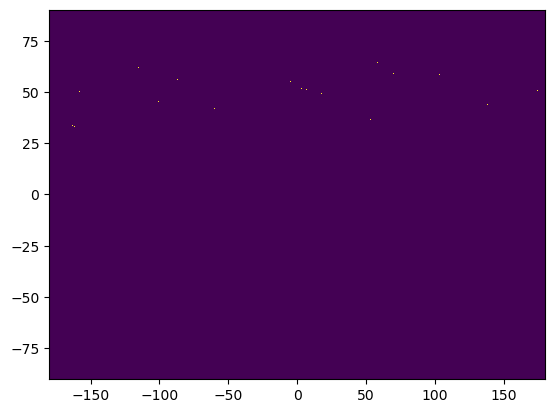

In [8]:
plt.pcolormesh(grid.x,grid.y,blocks[3])

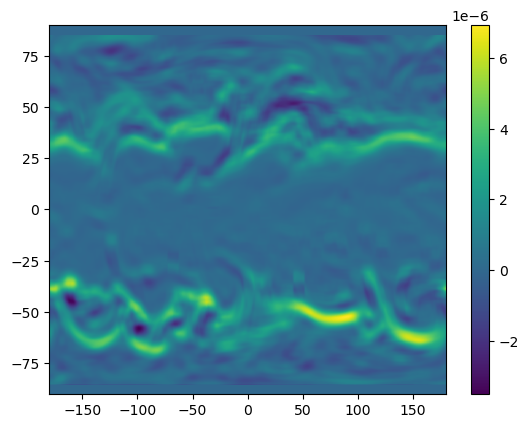

In [9]:
plt.pcolormesh(grid.x,grid.y,bi[3])
plt.colorbar()
#plt.pcolormesh(grid.x,grid.y,blocks[3])

In [54]:
import numpy as np
from scipy.ndimage import label

def find_regions_above_threshold(arr, local_minima, threshold):
    # Create a boolean mask for values above the threshold
    above_threshold = arr > threshold

    # Create an empty array to store the final regions
    regions = np.zeros_like(arr, dtype=bool)

    # Mark all areas connected to each local minimum
    labeled_array, num_features = label(above_threshold)
    for (i, j) in local_minima:
        # Always mark the local minima point itself as True
        regions[i, j] = True
        
        if above_threshold[i, j]:
            # Find the label of the connected region that includes this local minimum
            region_label = labeled_array[i, j]
            if region_label > 0:
                # Include the entire region in the final regions array
                regions |= (labeled_array == region_label)

    return regions



In [50]:
# Test example
np.random.seed(0)  # Set seed for reproducibility
test_array = np.random.rand(100, 100)  # Generate random 100x100 array

# Let's assume these are the local minima (for simplicity, random points)
local_minima = [(10, 10), (20, 50), (70, 80), (90, 30)]

# Set a threshold
threshold = 0.5

# Call the function
regions = find_regions_above_threshold(test_array, local_minima, threshold)

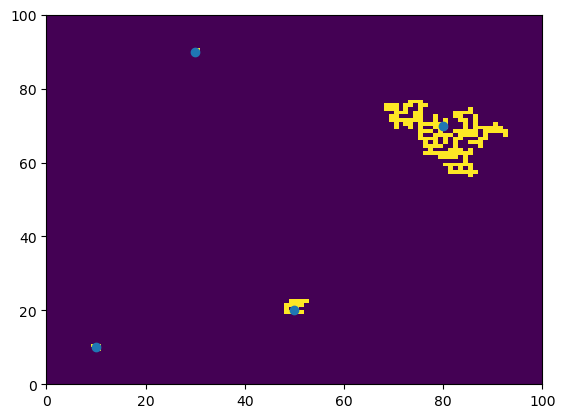

In [53]:
plt.pcolormesh(regions*1)
plt.scatter([x[1] for x in local_minima],
            [x[0] for x in local_minima])

In [30]:
def minimum_connect(res, nx, ny, dat, i, j, thres=0.0, grid_cyclic_ew=True):
    """
    Recursively find points above a threshold connected to a given point.
    
    Parameters
    ----------
    res : np.ndarray
        Mask of areas connected to any of the seeds and above the given threshold.
    nx : int
        Grid size in x-direction.
    ny : int
        Grid size in y-direction.
    dat : np.ndarray
        Data array with shape (ny, nx).
    i : int
        Current x-coordinate.
    j : int
        Current y-coordinate.
    thres : float
        Minimum threshold.
    grid_cyclic_ew : bool
        Whether the grid is cyclic east-west.
    """

    print(i,j)
    # North
    if j > 0 and dat[j-1, i] >= thres and not res[j-1, i]:
        res[j-1, i] = True
        minimum_connect(res, nx, ny, dat, i, j-1, thres, grid_cyclic_ew)
    
    # South
    if j < ny - 1 and dat[j+1, i] >= thres and not res[j+1, i]:
        res[j+1, i] = True
        minimum_connect(res, nx, ny, dat, i, j+1, thres, grid_cyclic_ew)
    
    # West
    if i > 0 and dat[j, i-1] >= thres and not res[j, i-1]:
        res[j, i-1] = True
        minimum_connect(res, nx, ny, dat, i-1, j, thres, grid_cyclic_ew)
    
    # East
    if i < nx - 1 and dat[j, i+1] >= thres and not res[j, i+1]:
        res[j, i+1] = True
        minimum_connect(res, nx, ny, dat, i+1, j, thres, grid_cyclic_ew)
    
    # Periodic boundary West
    if grid_cyclic_ew and i == 0 and dat[j, nx-1] >= thres and not res[j, nx-1]:
        res[j, nx-1] = True
        minimum_connect(res, nx, ny, dat, nx-1, j, thres, grid_cyclic_ew)
    
    # Periodic boundary East
    if grid_cyclic_ew and i == nx-1 and dat[j, 0] >= thres and not res[j, 0]:
        res[j, 0] = True
        minimum_connect(res, nx, ny, dat, 0, j, thres, grid_cyclic_ew)


def mask_minimum_connect(dat, seeds, thres=0.0, **kwargs):
    """
    Masks areas above a given threshold and connected to a list of seed points.

    Parameters
    ----------
    dat : np.ndarray of shape (ny, nx) and dtype float64
        Data to which the threshold is applied.
    seeds : np.ndarray of shape (ns, 2) and dtype int32
        Array of j and i indexes of seed points.
    thres : float
        Minimum threshold.

    Returns
    -------
    res : np.ndarray of shape (ny, nx) and dtype bool
        Mask of areas connected to any of the seeds and above the given threshold.
    """
    
    ny, nx = dat.shape
    ns = seeds.shape[0]
    
    # Initialize the result array
    res = np.zeros((ny, nx), dtype=bool)
    
    for n in range(ns):
        j, i = seeds[n]
        #i=i-1; j=j-1
        
        # Check if the seed point is below the threshold
        if dat[j, i] < thres:
            raise ValueError(f"FATAL Error: seed {n + 1} itself below threshold.")
        
        # Start connecting from the seed point if not already connected
        if not res[j, i]:
            res[j, i] = True
            minimum_connect(res, nx, ny, dat, i, j, thres=thres)

    return res

In [68]:
tlen=grid.nt
min_duration=4
dat=pv.pv.values

In [69]:
import numpy as np
from scipy.ndimage import label

def find_regions_above_threshold(arr, local_minima, threshold):
    # Create a boolean mask for values above the threshold
    above_threshold = arr > threshold

    # Create an empty array to store the final regions
    regions = np.zeros_like(arr, dtype=bool)

    # Mark all areas connected to each local minimum
    labeled_array, num_features = label(above_threshold)
    for (i, j) in local_minima:
        i=i-1;j=j-1
        regions[i, j] = True
        
        if above_threshold[i, j]:
            # Find the label of the connected region that includes this local minimum
            region_label = labeled_array[i, j]
            if region_label > 0:
                # Include the entire region in the final regions array
                regions |= (labeled_array == region_label)

    return regions



In [70]:
#seeds[tidx]

In [71]:
#from utils import utils

# Create an list of seeds.
print('Stage 3: Applying minimum duration criterion and write out block masks')
seeds = []
for tidx in range(tlen):
    seeds.append([])
for block in blocks:
    if len(block['blockidx']) >= min_duration:
        tidx0 = list(grid.t_parsed).index(block['onset'])
        for dtidx in range(len(block['blockidx'])):
            pos = block['pos'][dtidx]
            # convert to Fortran indexes
            seeds[tidx0+dtidx].append([pos[0]+1, pos[1]+1])

blockmask = np.zeros(dat.shape, dtype='bool')
for tidx in range(bi.shape[0]):
    if len(seeds[tidx]) > 0:
        blockmask[tidx,j0:j1,:] = find_regions_above_threshold(
                bi[tidx,:,:], 
                np.array(seeds[tidx], dtype='i4'), 
                threshold=0.0
        )

blockmask = blockmask.astype('i1')

Stage 3: Applying minimum duration criterion and write out block masks


NameError: name 'j0' is not defined

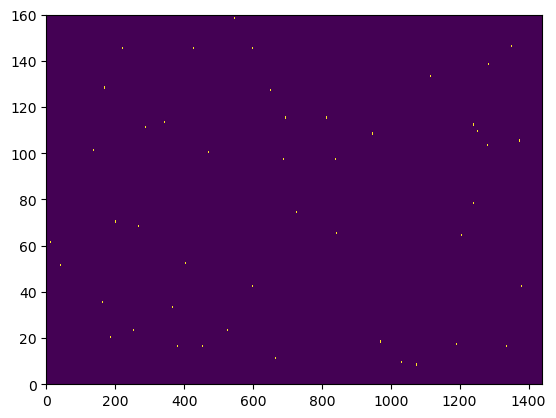

In [44]:
plt.pcolormesh(black_mask*1)

In [24]:
ny, nx = dat.shape
ns = seeds.shape[0]

# Initialize the result array
res = np.zeros((ny, nx), dtype=bool)

for n in range(ns):
    j, i = seeds[n]
    
    # Check if the seed point is below the threshold
    if dat[j, i] < thres:
        raise ValueError(f"FATAL Error: seed {n + 1} itself below threshold.")

ValueError: too many values to unpack (expected 2)

In [ ]:
from utils import utils

# Create an list of seeds.
print('Stage 3: Applying minimum duration criterion and write out block masks')
seeds = []
for tidx in range(tlen):
    seeds.append([])
for block in blocks:
    if len(block['blockidx']) >= min_duration:
        tidx0 = list(grid.t_parsed).index(block['onset'])
        for dtidx in range(len(block['blockidx'])):
            pos = block['pos'][dtidx]
            # convert to Fortran indexes
            seeds[tidx0+dtidx].append([pos[0]+1, pos[1]+1])

blockmask = np.zeros(dat.shape, dtype='bool')
for tidx in range(bi.shape[0]):
    if len(seeds[tidx]) > 0:
        blockmask[tidx,j0:j1,:] = mask_minimum_connect(
                bi[tidx,:,:], 
                np.array(seeds[tidx], dtype='i4'), 
                thres=0.0
        )

blockmask = blockmask.astype('i1')

In [ ]:
blockmask

In [12]:
from detect_cyclones import cyclone_by_lapmsl
cyclones, tracked_cyclones, tracks, prev_cyc, unfinished_tracks=cyclone_by_lapmsl(msl.msl.isel(time=slice(0,10)).values, gridobj)

Preparation:   12.8 seconds.


KeyboardInterrupt: 

In [6]:
from detect_cyclones import cyclone_by_lapmsl
cyclones, tracked_cyclones, tracks, prev_cyc, unfinished_tracks=cyclone_by_lapmsl(msl.msl.isel(time=slice(0,10)).values, gridobj)

Preparation:   13.7 seconds.
Detection & tracking:  120.0 seconds.
Smoothing & trackinfo:    3.1 seconds.
Filtering & cleanup:    0.2 seconds.


Boolean Series key will be reindexed to match DataFrame index.


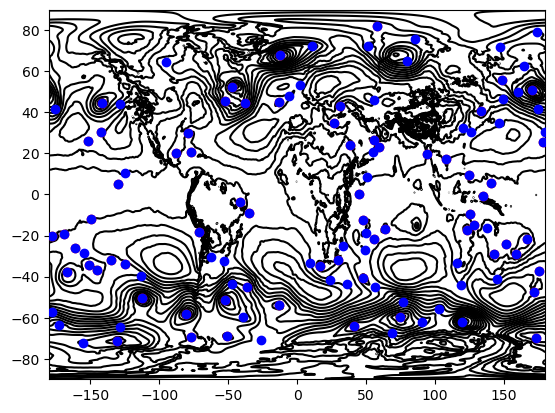

In [7]:
indt=datetime(2022,3,1,0,0,0)
#cyc_indt=cyclones[cyclones.track_id!=-1][cyclones.date==indt]
cyc_indt=cyclones[cyclones.closed==True][cyclones.date==indt]
plt.contour(msl.longitude,msl.latitude,msl.msl.sel(time=indt)/100,colors='black',levels=range(800,1060,4))
plt.scatter(cyc_indt.lon_raw,cyc_indt.lat_raw,zorder=1e10,color='red')
cyc_indt=cyclones[cyclones.date==indt]
plt.scatter(cyc_indt.lon_raw,cyc_indt.lat_raw,zorder=1e11,color='blue')

In [8]:
from derivatives_python import grad
Presx, Presy = grad(msl.msl.isel(time=slice(0,4)).values,grid.dx,grid.dy)

ModuleNotFoundError: No module named 'derivatives_python'

In [ ]:
from dynlib.dynfor import derivatives
Fresx, Fresy = derivatives.grad(msl.msl.isel(time=slice(0,4)).values,grid.dx,grid.dy)